# Olist Brazilian E-Commerce Customer Satisfaction Analysis

## Objective

This analysis examines customer satisfaction within the Olist Brazilian E-Commerce dataset. The primary objective is to determine whether order, delivery, product, payment, temporal, and geographic characteristics can help predict whether a customer leaves a positive review.

A positive review is defined as a review score of 4 or 5.

The analysis focuses on three questions:

1. Which order and fulfillment characteristics are associated with customer satisfaction?
2. Can positive customer reviews be predicted using available order information?
3. Which characteristics contribute most strongly to predictive performance?

The analysis combines exploratory data analysis with Logistic Regression, Random Forest, and Gradient Boosting classification models.

## 1. Data Loading and Preparation


### Import Libraries


In [ ]:
# ===================================
# Useful Imports
# ===================================

# Standard Libraries
import os
import time
import math
import io
import zipfile
import requests
from urllib.parse import urlparse
from itertools import chain, combinations

# Data Science Libraries
import numpy as np
import pandas as pd
# !pip install statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf



# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.ticker as mticker  # Optional: Format y-axis labels as dollars
import seaborn as sns

# Scikit-learn (Machine Learning)
from sklearn.model_selection import (
    train_test_split, 
    cross_val_score, 
    GridSearchCV, 
    RandomizedSearchCV, 
    RepeatedKFold
)
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.feature_selection import SequentialFeatureSelector, f_regression, SelectKBest
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.ensemble import BaggingRegressor, RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier
from sklearn.decomposition import PCA

# Progress Tracking

# !pip install tqdm 
from tqdm import tqdm

# =============================
# Global Variables
# =============================
random_state = 0

# =============================
# Utility Functions
# =============================

# Format y-axis labels as dollars with commas (optional)
def dollar_format(x, pos):
    return f'${x:,.0f}'

# Convert seconds to HH:MM:SS format
def format_hms(seconds):
    return time.strftime("%H:%M:%S", time.gmtime(seconds))



### Load Raw Datasets


Source: [Olist Brazilian E-Commerce Public Dataset](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)


In [70]:
#LOAD ALL 9 DATASETS 
customersdf = pd.read_csv('olist_customers_dataset.csv')
ordersdf = pd.read_csv('olist_orders_dataset.csv')
itemsdf = pd.read_csv('olist_order_items_dataset.csv')
paymentsdf = pd.read_csv('olist_order_payments_dataset.csv')
reviewsdf = pd.read_csv('olist_order_reviews_dataset.csv')
productsdf = pd.read_csv('olist_products_dataset.csv')
sellersdf = pd.read_csv('olist_sellers_dataset.csv')
geodf = pd.read_csv('olist_geolocation_dataset.csv')
translationdf = pd.read_csv('product_category_name_translation.csv')


### Inspect Raw Tables


In [71]:
#check column names of all dfs
for name, df in {
    "customers": customersdf,
    "orders": ordersdf,
    "items": itemsdf,
    "payments": paymentsdf,
    "reviews": reviewsdf,
    "products": productsdf,
    "sellers": sellersdf,
    "geo" : geodf,
    "translation" : translationdf
}.items():
    print(name, df.columns)


customers Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')
orders Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')
items Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')
payments Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')
reviews Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')
products Index(['product_id', 'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qt

### Investigate Initial Merge

A direct merge helps inspect table relationships, but orders with multiple items and payments produce many-to-many duplication. The original investigation found 117,329 rows for 97,916 unique orders; the most repeated order had 3 items × 21 payment records. This exploratory merge motivates the order-level aggregation below.


In [72]:
#initial direct merge --> investigate repeated orders

df = ordersdf.merge(itemsdf, on ='order_id')
df = df.merge(productsdf, on='product_id')
df = df.merge(paymentsdf, on='order_id')
df = df.merge(reviewsdf, on='order_id')
df = df.merge(customersdf, on='customer_id')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,87285b34884572647811a353c7ac498a,...,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"Não testei o produto ainda, mas ele veio corre...",2017-10-11 00:00:00,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,595fac2a385ac33a80bd5114aec74eb8,...,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,aa4383b373c6aca5d8797843e5594415,...,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18 00:00:00,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [ ]:
#check duplication --> rows vs unique orders
display(df.shape, df['order_id'].nunique())

#how many repeats of same order
df['order_id'].value_counts().head(10)


In [75]:
# Look at most repeated order
top_order = df['order_id'].value_counts().index[0]

df[df['order_id'] == top_order][[
    'order_id',
    'order_item_id',
    'product_id',
    'price',
    'payment_sequential',
    'payment_value',
    'review_id'
]]

,order_id,order_item_id,product_id,price,payment_sequential,payment_value,review_id
84228,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,17,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84229,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,1,2.61,eef5dbca8d37dfce6db7d7b16dd0525e
84230,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,13,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84231,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,16,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84232,895ab968e7bb0d5659d16cd74cd1650c,1,ebf9bc6cd600eadd681384e3116fda85,12.99,19,0.24,eef5dbca8d37dfce6db7d7b16dd0525e
...,...,...,...,...,...,...,...
84286,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,15,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84287,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,20,4.61,eef5dbca8d37dfce6db7d7b16dd0525e
84288,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,14,16.70,eef5dbca8d37dfce6db7d7b16dd0525e
84289,895ab968e7bb0d5659d16cd74cd1650c,3,5ddab10d5e0a23acb99acf56b62b3276,83.80,9,2.61,eef5dbca8d37dfce6db7d7b16dd0525e


In [76]:
#NOTE - only 3 order items but x 21 payment records
df[df['order_id'] == top_order][
    ['order_item_id', 'payment_sequential']
].drop_duplicates()

,order_item_id,payment_sequential
84228,1,17
84229,1,1
84230,1,13
84231,1,16
84232,1,19
...,...,...
84286,3,15
84287,3,20
84288,3,14
84289,3,9


### Create Final Order-Level Dataset

The final unit of analysis is **one row per order**. Aggregate items, payments, and reviews before merging to prevent row multiplication and inflated totals. Then add customer information, the primary payment type, and the translated primary product category.


In [78]:
# 1) AGGREGATE ORDER ITEMS
items_agg = itemsdf.groupby('order_id').agg(
    total_price=('price', 'sum'),
    total_freight=('freight_value', 'sum'),
    num_items=('order_item_id', 'count')
).reset_index()


# 2) AGGREGATE PAYMENTS
payments_agg = paymentsdf.groupby('order_id').agg(
    total_payment=('payment_value', 'sum'),
    num_payments=('payment_sequential', 'count'),
    payment_installments=('payment_installments', 'max')
).reset_index()


# 3) AGGREGATE REVIEWS
reviews_agg = reviewsdf.groupby('order_id').agg(
    review_score=('review_score', 'mean')
).reset_index()


# 4) GET PRIMARY PAYMENT TYPE
primary_payment = (
    paymentsdf
    .sort_values('payment_value', ascending=False)
    .drop_duplicates('order_id')
    [['order_id', 'payment_type']]
    .rename(columns={'payment_type': 'primary_payment_type'})
)


# 5) GET PRIMARY PRODUCT CATEGORY
items_products = itemsdf.merge(
    productsdf[['product_id', 'product_category_name']],
    on='product_id',
    how='left'
)

#translate product categories
items_products = items_products.merge(
    translationdf,
    on='product_category_name',
    how='left'
)

primary_category = (
    items_products
    .sort_values('price', ascending=False)
    .drop_duplicates('order_id')
    [['order_id', 'product_category_name_english']]
    .rename(columns={'product_category_name_english': 'primary_product_category'})
)
display(primary_category)

,order_id,primary_product_category
3556,0812eb902a67711a1cb742b3cdaa65ae,housewares
112233,fefacc66af859508bf1a7934eab1e97f,computers
107841,f5136e38d1a14a4dbd87dff67da82701,art
74336,a96610ab360d42a2e5335a3998b4718a,small_appliances
11249,199af31afc78c699f0dbf71fb178d4d4,small_appliances
...,...,...
24916,38bcb524e1c38c2c1b60600a80fc8999,pet_shop
102500,e8bbc1d69fee39eee4c72cb5c969e39d,stationery
106405,f1d5c2e6867fa93ceee9ef9b34a53cbf,health_beauty
48625,6e864b3f0ec71031117ad4cf46b7f2a1,construction_tools_construction


In [80]:
# 6) CREATE FINAL ORDER-LEVEL DATASET
analysis_df = ordersdf.merge(items_agg, on='order_id', how='left')

analysis_df = analysis_df.merge(
    payments_agg, on='order_id', how='left'
)

analysis_df = analysis_df.merge(
    reviews_agg, on='order_id', how='left'
)

analysis_df = analysis_df.merge(
    customersdf, on='customer_id', how='left'
)

#primary payment
analysis_df = analysis_df.merge(
    primary_payment, on='order_id', how='left'
)

#primary category
analysis_df = analysis_df.merge(
    primary_category, on='order_id', how='left'
)


### Verify the Final Dataset


In [81]:
#verify final dataset --> 1 row per order
#shape, unique orders, preview
display(
    analysis_df.shape,
    analysis_df['order_id'].nunique(),
    analysis_df.head()
)


(99441, 21)

99441

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,...,total_payment,num_payments,payment_installments,review_score,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,primary_payment_type,primary_product_category
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,8.72,...,38.71,3.0,1.0,4.0,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,voucher,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,22.76,...,141.46,1.0,1.0,4.0,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,boleto,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,19.22,...,179.12,1.0,3.0,5.0,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,credit_card,auto
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,27.20,...,72.20,1.0,1.0,5.0,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,credit_card,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,8.72,...,28.62,1.0,1.0,5.0,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,credit_card,stationery


## 2. Feature Engineering


### Convert Timestamps


In [86]:
# convert dates to datetime
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    analysis_df[col] = pd.to_datetime(analysis_df[col])

### Create Delivery and Purchase-Time Features


In [87]:
# Days from purchase → delivery
analysis_df['delivery_days'] = (
    analysis_df['order_delivered_customer_date'] -
    analysis_df['order_purchase_timestamp']
).dt.days

# Difference between actual and estimated delivery
analysis_df['delivery_delay'] = (
    analysis_df['order_delivered_customer_date'] -
    analysis_df['order_estimated_delivery_date']
).dt.days

    #delay < 0 = arrived early, >0  = arrived late

#create late_delivery
analysis_df['late_delivery'] = (
    analysis_df['delivery_delay'] > 0
).astype(int)

#purchase-time features
analysis_df['purchase_month'] = (
    analysis_df['order_purchase_timestamp'].dt.month
)

analysis_df['purchase_dayofweek'] = (
    analysis_df['order_purchase_timestamp'].dt.dayofweek
)

### Inspect Feature Distributions


In [88]:
#check statistics 
analysis_df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,total_price,total_freight,num_items,total_payment,num_payments,payment_installments,review_score,customer_zip_code_prefix,delivery_days,delivery_delay,late_delivery,purchase_month,purchase_dayofweek
count,99441,99281,97658,96476,99441,98666.000000,98666.000000,98666.000000,99440.000000,99440.000000,99440.000000,98673.000000,99441.000000,96476.000000,96476.000000,99441.000000,99441.000000,99441.000000
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232,137.754076,22.823562,1.141731,160.990267,1.044710,2.930521,4.086793,35137.474583,12.094086,-11.876881,0.065717,6.032220,2.755735
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00,0.850000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,1003.000000,0.000000,-147.000000,0.000000,1.000000,0.000000
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00,45.900000,13.850000,1.000000,62.010000,1.000000,1.000000,4.000000,11347.000000,6.000000,-17.000000,0.000000,3.000000,1.000000
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00,86.900000,17.170000,1.000000,105.290000,1.000000,2.000000,5.000000,24416.000000,10.000000,-12.000000,0.000000,6.000000,3.000000
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00,149.900000,24.040000,1.000000,176.970000,1.000000,4.000000,5.000000,58900.000000,15.000000,-7.000000,0.000000,8.000000,4.000000
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00,13440.000000,1794.960000,21.000000,13664.080000,29.000000,24.000000,5.000000,99990.000000,209.000000,188.000000,1.000000,12.000000,6.000000
std,NaN,NaN,NaN,NaN,NaN,210.645145,21.650909,0.538452,221.951257,0.381166,2.715685,1.346274,29797.938996,9.551746,10.183854,0.247789,3.232999,1.966495


In [89]:
analysis_df['order_status'].value_counts()
    #about 3000 orders not delivered

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [90]:
analysis_df['customer_state'].value_counts().head()
    #most from Sao Paulo

customer_state
SP    41746
RJ    12852
MG    11635
RS     5466
PR     5045
Name: count, dtype: int64

In [91]:
analysis_df['review_score'].value_counts().sort_index()

review_score
1.000000    11316
1.500000        8
2.000000     3125
2.500000       34
3.000000     8136
3.333333        1
3.500000       25
4.000000    19018
4.333333        1
4.500000       54
5.000000    56955
Name: count, dtype: int64

### Define Positive Reviews


In [92]:
# 1 = positive review (4 or higher)
# 0 = negative/neutral review (below 4)
analysis_df['positive_review'] = (
    analysis_df['review_score'] >= 4
).astype(int)

In [93]:
#class balance
analysis_df['positive_review'].value_counts()
analysis_df['positive_review'].value_counts(normalize=True)

positive_review
1    0.764554
0    0.235446
Name: proportion, dtype: float64

### Create the Reviewed-Order Dataset

Exclude missing review scores from `model_df` so they are not treated as non-positive reviews. Keep `analysis_df` for general EDA; use `model_df` for review-rate comparisons and modeling.


In [94]:
#model_df
model_df = analysis_df.dropna(subset=['review_score']).copy()

#target
model_df['positive_review'] = (
    model_df['review_score'] >= 4
).astype(int)

display(
    model_df['positive_review'].value_counts(),
    model_df['positive_review'].value_counts(normalize=True)
)

positive_review
1    76028
0    22645
Name: count, dtype: int64

positive_review
1    0.770505
0    0.229495
Name: proportion, dtype: float64

### Data Preparation Summary

- Combined Olist order, item, payment, review, and customer data.
- Identified duplicate order IDs caused by one-to-many relationships between orders, items, payments, and reviews.
- Aggregated order items and payments before merging to prevent many-to-many row multiplication.
- Aggregated multiple reviews to one review score per order.
- Created `analysis_df` with one row per unique order (99,441 orders).
- Converted delivery timestamps for subsequent feature engineering.
- Identified a small number of anomalous delivery timestamps for later consideration.
- Created `model_df` for modeling, with no NaN review_score, and `positive_review` target feature ('review_score' >=4)
    - 77.1% positive

## 3. Exploratory Data Analysis


### Review Score Distribution


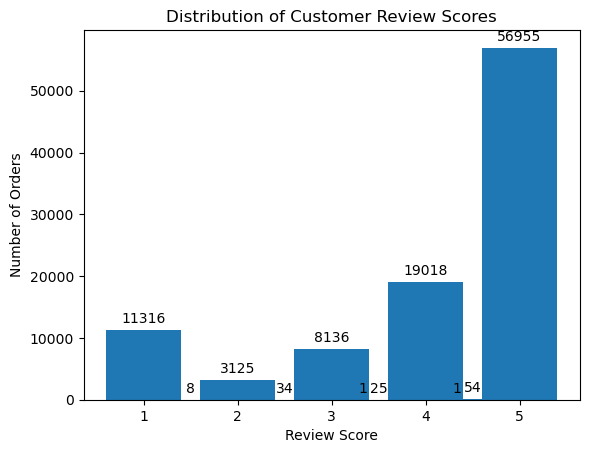

In [95]:
# EDA Figure 1: Review Score Distribution

review_counts = analysis_df['review_score'].value_counts().sort_index()

bars = plt.bar(review_counts.index, review_counts.values)

plt.xlabel('Review Score')
plt.ylabel('Number of Orders')
plt.title('Distribution of Customer Review Scores')
plt.xticks([1, 2, 3, 4, 5])

# Add count labels
plt.bar_label(
    bars,
    labels=[f'{x}' for x in review_counts.values],
    padding=3
)

plt.show()

### Do late deliveries affect positive reviews?

In [96]:
# Positive review rate by delivery status
late_review_rate = (
    model_df
    .dropna(subset=['delivery_delay']) #bc Nan here = 0 for late_delivery, affects averages
    .groupby('late_delivery')['positive_review']
    .agg(['mean', 'count'])
)
late_review_rate
#82% pos reviews for on-time/early, 26% positive reviews for late delivery

,mean,count
late_delivery,,
0,0.826335,89448
1,0.267314,6382


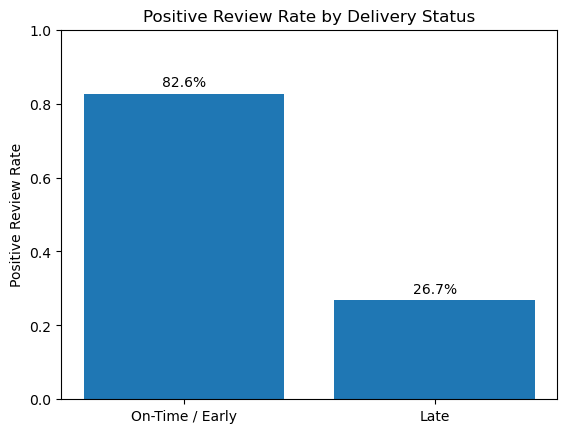

In [97]:
# EDA Figure 2: Review Rate by Delivery Status
delivery_review = (
    model_df
    .dropna(subset=['delivery_delay'])
    .groupby('late_delivery')['positive_review']
    .mean()
)

bars = plt.bar(
    ['On-Time / Early', 'Late'],
    delivery_review.values
)

plt.ylabel('Positive Review Rate')
plt.title('Positive Review Rate by Delivery Status')
plt.ylim(0, 1)

# Add percentage labels
plt.bar_label(
    bars,
    labels=[f'{x:.1%}' for x in delivery_review.values],
    padding=3
)

plt.show()

### Does "how late" matter?

In [98]:
#All review scores, with average delay values
model_df.groupby('review_score')['delivery_delay'].mean()

review_score
1.000000    -4.026191
1.500000    -6.000000
2.000000    -8.635460
2.500000    -7.566667
3.000000   -10.779687
3.333333   -14.000000
3.500000   -13.956522
4.000000   -12.379584
4.333333   -11.000000
4.500000   -13.037736
5.000000   -13.383435
Name: delivery_delay, dtype: float64

In [99]:
# Keep standard review scores (1-5)
review_delay = (
    model_df[model_df['review_score'].isin([1, 2, 3, 4, 5])]
    .groupby('review_score')['delivery_delay']
    .mean()
)
review_delay

review_score
1.0    -4.026191
2.0    -8.635460
3.0   -10.779687
4.0   -12.379584
5.0   -13.383435
Name: delivery_delay, dtype: float64

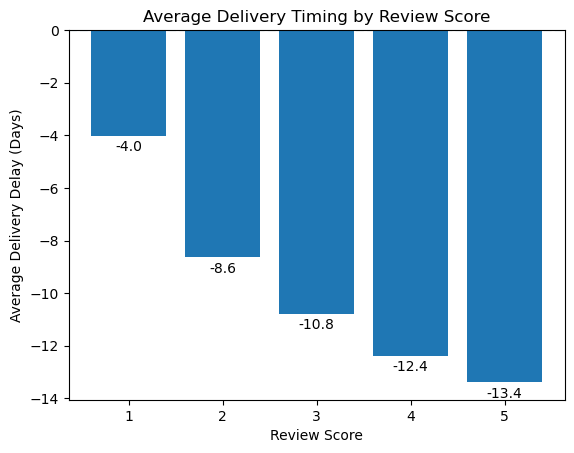

In [100]:
# EDA Figure 3 - Average Delivery Timing by Review Score

bars = plt.bar(
    review_delay.index,
    review_delay.values
)

plt.xlabel('Review Score')
plt.ylabel('Average Delivery Delay (Days)')
plt.title('Average Delivery Timing by Review Score')
plt.xticks([1, 2, 3, 4, 5])

# Reference line: 0 = estimated delivery date
plt.axhline(0, linestyle='--')

plt.bar_label(
    bars,
    labels=[f'{x:.1f}' for x in review_delay.values],
    padding=3
)

plt.show()

### Order Characteristics and Correlations


In [101]:
#compare numeric features by positive review
model_df.groupby('positive_review')[
    ['total_price',
     'total_freight',
     'num_items',
     'total_payment',
     'payment_installments',
     'delivery_days',
     'delivery_delay']
].mean().T

positive_review,0,1
total_price,149.393563,134.099401
total_freight,25.994663,21.879883
num_items,1.245555,1.110516
total_payment,176.633152,155.987593
payment_installments,3.081258,2.882491
delivery_days,17.407768,10.621595
delivery_delay,-7.354330,-13.132690


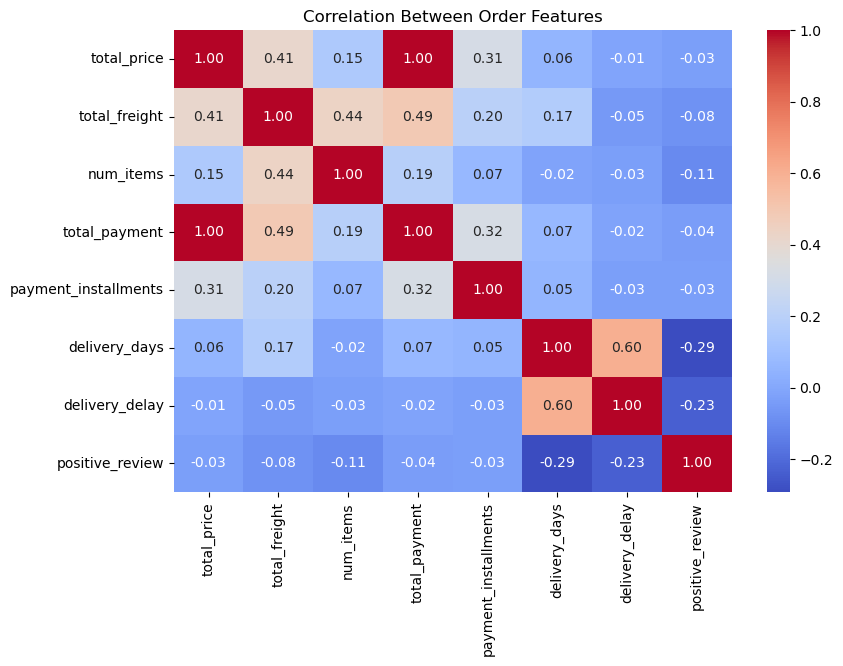

In [102]:
# Numeric features
corr_cols = [
    'total_price',
    'total_freight',
    'num_items',
    'total_payment',
    'payment_installments',
    'delivery_days',
    'delivery_delay',
    'positive_review'
]

corr = model_df[corr_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Between Order Features')
plt.show()

- total_price ↔ total_payment = 1.00 → essentially redundant. Can drop total_payment from ML and keep total_price.
- delivery_days ↔ positive review = −0.29 → strongest linear relationship with the target.
- delivery_delay ↔ positive review = −0.23 → also meaningful.
- Price, freight, installments, etc. individually have fairly weak linear relationships with satisfaction.
- delivery_days and delivery_delay correlate at 0.60 --> overall wait time vs whether Olist met its promised date.
- TLDR = delivery performance seems to have more association with customer satisfaction than order cost/payment features.

## 4. Predictive Modeling


### Select Features and Target


In [103]:
numeric_features = [  #6 
    'total_price',  #price
    'total_freight',    #shipping cost
    'num_items',    #order size
    'payment_installments', #payment behavior
    'delivery_days',    #overall delivery speed
    'delivery_delay'    #performance
]

categorical_features = [
    'primary_payment_type',
    'primary_product_category',
    'customer_state',
    'purchase_month',
    'purchase_dayofweek'
]

features = numeric_features + categorical_features
target = 'positive_review'

In [104]:
# Keep only orders with known delivery outcomes
model_df = model_df.dropna(
    subset=['delivery_days', 'delivery_delay']
).copy()

# Build X and y
X = model_df[features].copy()
y = model_df[target].copy()

X.shape, y.shape    #95830 rows

((95830, 11), (95830,))

### Train/Test Split


In [105]:
#SPLIT DATA
# 2) TRAIN / TEST SPLIT

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=0,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

print("\nTrain target:")
print(y_train.value_counts(normalize=True))

print("\nTest target:")
print(y_test.value_counts(normalize=True))

Train: (76664, 11)
Test: (19166, 11)

Train target:
positive_review
1    0.789106
0    0.210894
Name: proportion, dtype: float64

Test target:
positive_review
1    0.789106
0    0.210894
Name: proportion, dtype: float64


### Preprocess Numeric and Categorical Features


In [106]:
# 3) Impute NaN with median, one-hot encode categorical

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())    #good for regression
])

# Categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'    #unknown value
    )),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore'
    ))
])

# Combine numeric + categorical preprocessing
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

### Logistic Regression

In [107]:
# 1) LOGISTIC REGRESSION BASELINE

from sklearn.linear_model import LogisticRegression

log_model = Pipeline([
    ('preprocessor', preprocessor), #transform num and cat
    ('model', LogisticRegression(
        max_iter=1000,
        random_state=0
    ))
])

log_model.fit(X_train, y_train)

# Predictions
y_pred_log = log_model.predict(X_test)
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [108]:
#Evaluate
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
log_results = {
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, y_pred_log),
    'Precision': precision_score(y_test, y_pred_log),
    'Recall': recall_score(y_test, y_pred_log),
    'F1': f1_score(y_test, y_pred_log),
    'ROC-AUC': roc_auc_score(y_test, y_prob_log)
}
log_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.8130021913805697,
 'Precision': 0.8192077893339235,
 'Recall': 0.9791060565987834,
 'F1': 0.8920481927710844,
 'ROC-AUC': 0.6965984051877399}

- good at identifying positive reviews 97.9%
- bad at classify non-positive = only 776/4042 correct
- SMALL IMPROVEMENT from baseline -> 77% -> 81.3% 

In [109]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, y_pred_log)

array([[  774,  3268],
       [  316, 14808]])

### Random Forest

In [110]:
# RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

# Preprocessing for tree models
tree_numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median'))
])

tree_categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(
        strategy='constant',
        fill_value='Unknown'
    )),
    ('onehot', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ))
])

tree_preprocessor = ColumnTransformer([
    ('num', tree_numeric_transformer, numeric_features),
    ('cat', tree_categorical_transformer, categorical_features)
])


In [111]:
#build and train
rf_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=0,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [112]:
#results
rf_results = {
    'Model': 'Random Forest',
    'Accuracy': accuracy_score(y_test, y_pred_rf),
    'Precision': precision_score(y_test, y_pred_rf),
    'Recall': recall_score(y_test, y_pred_rf),
    'F1': f1_score(y_test, y_pred_rf),
    'ROC-AUC': roc_auc_score(y_test, y_prob_rf)
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 0.822602525305228,
 'Precision': 0.825811471765229,
 'Recall': 0.9824120603015075,
 'F1': 0.8973305954825462,
 'ROC-AUC': 0.6965674880823556}

- 0.69 ROC-AUC similar, suggests adding nonlinear relationships hasn't dramatically improved the model's ability to separate positive from non-positive reviews.

### Gradient Boosting

In [113]:
from sklearn.ensemble import HistGradientBoostingClassifier

gb_model = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_leaf_nodes=31,
        random_state=0
    ))
])

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

In [114]:
#results
gb_results = {
    'Model': 'Gradient Boosting',
    'Accuracy': accuracy_score(y_test, y_pred_gb),
    'Precision': precision_score(y_test, y_pred_gb),
    'Recall': recall_score(y_test, y_pred_gb),
    'F1': f1_score(y_test, y_pred_gb),
    'ROC-AUC': roc_auc_score(y_test, y_prob_gb)
}

gb_results

{'Model': 'Gradient Boosting',
 'Accuracy': 0.822602525305228,
 'Precision': 0.8256304855016109,
 'Recall': 0.98274266067178,
 'F1': 0.8973615890841031,
 'ROC-AUC': 0.7063543305082406}

- Models achieved moderate discrimination of positive versus non-positive reviews, with Gradient Boosting reaching ROC-AUC ≈ 0.706. Performance suggests that order, product, geographic, payment, time, and delivery characteristics contain predictive information, but do not fully explain customer review outcomes.

## 5. Feature Importance


In [132]:
#GB permutation importances
from sklearn.inspection import permutation_importance

#randomly shuffle 1 feature, recalculate ROC-AUC 
#to see its importance
perm_importance = permutation_importance(
    gb_model,
    X_test,
    y_test,
    scoring='roc_auc',
    n_repeats=5,
    random_state=0,
    n_jobs=-1
)
#create df
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean,
    'Std': perm_importance.importances_std
}).sort_values(
    'Importance',
    ascending=False
)

importance_df

,Feature,Importance,Std
4,delivery_days,0.045583,0.003575
5,delivery_delay,0.039294,0.002183
2,num_items,0.038658,0.003490
7,primary_product_category,0.010790,0.000997
0,total_price,0.004155,0.000791
1,total_freight,0.004032,0.000364
3,payment_installments,0.001293,0.000584
8,customer_state,0.001061,0.000622
9,purchase_month,0.000694,0.001224
6,primary_payment_type,-0.000082,0.000324


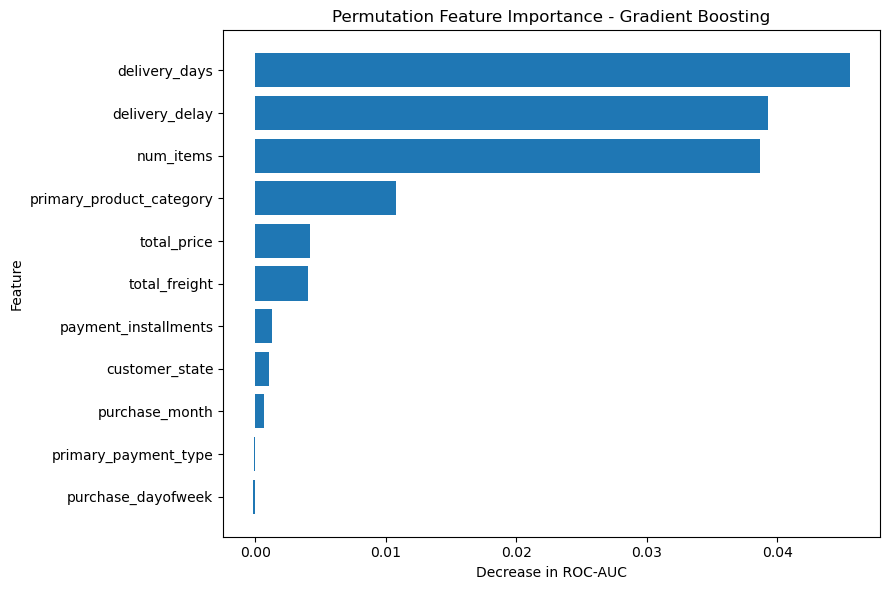

In [133]:
# GRAPH FEATURE IMPORTANCE: Best Gradient Boosting Model

#sort highest --> lowest importance for graph
importance_plot = (
    importance_df
    .sort_values('Importance', ascending=True)
)

plt.figure(figsize=(9, 6))

#horizontal bar plot --> easier to read feature names
plt.barh(
    importance_plot['Feature'],
    importance_plot['Importance']
)

plt.xlabel('Decrease in ROC-AUC')
plt.ylabel('Feature')
plt.title('Permutation Feature Importance - Gradient Boosting')

plt.tight_layout()
plt.show()

- Delivery performance, delivery delay, and number of items were the most important predictors, indicating that delivery performance and order complexity were most strongly associated with customer satisfaction.
- payment method, purchase timing, and geography provided relatively little additional predictive information. 
- (Product category provided a smaller but meaningful contribution.)

## 6. Follow-Up Analysis

### Order Size and Delivery Time


In [116]:
#Explore num_items more
item_review_summary = (
    model_df
    .groupby('num_items')
    .agg(
        orders=('order_id', 'count'),
        positive_review_rate=('positive_review', 'mean'),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_delivery_delay=('delivery_delay', 'mean')
    )
)

item_review_summary.head(15)

#10+ item orders rare, so group them
model_df['item_group'] = pd.cut(
    model_df['num_items'],
    bins=[0, 1, 2, 3, 5, float('inf')],
    labels=['1', '2', '3', '4-5', '6+']
)

item_group_summary = (
    model_df
    .groupby('item_group', observed=True)
    .agg(
        orders=('order_id', 'count'),
        positive_review_rate=('positive_review', 'mean'),
        avg_delivery_days=('delivery_days', 'mean')
    )
)

item_group_summary

,orders,positive_review_rate,avg_delivery_days
item_group,,,
1,86301,0.805912,12.134622
2,7320,0.650137,11.313934
3,1286,0.609642,11.105754
4-5,680,0.577941,11.635294
6+,243,0.547325,11.415638


- Customer satisfaction decreased as order size increased. 
- (Single-item orders had an 80.6% positive-review rate compared with 54.7% for orders containing six or more items.)
- EVEN THOUGH Average delivery duration remained relatively stable across order sizes

### Product Categories and Customer Satisfaction


In [123]:
#Groupby Product Category - statistics
category_summary = (
    model_df
    .groupby('primary_product_category')
    .agg(
        orders=('order_id', 'count'),
        positive_review_rate=('positive_review', 'mean'),
        avg_delivery_days=('delivery_days', 'mean'),
        avg_delivery_delay=('delivery_delay', 'mean'),
        avg_order_value=('total_price', 'mean')
    )
)

# Only categories with at least 500 orders
category_summary_500 = (
    category_summary[
        category_summary['orders'] >= 500
    ]
    .sort_values('positive_review_rate', ascending=True)
)

lowest_categories = category_summary_500.head(10)
lowest_categories

,orders,positive_review_rate,avg_delivery_days,avg_delivery_delay,avg_order_value
primary_product_category,,,,,
office_furniture,1241,0.635778,20.137792,-11.839645,214.536567
bed_bath_table,9091,0.742053,12.484985,-11.399736,111.592014
telephony,4049,0.760435,12.480859,-11.237590,75.913290
furniture_decor,6141,0.763556,12.622537,-12.301417,114.552203
computers_accessories,6480,0.772377,12.701852,-12.390895,136.499898
baby,2738,0.775383,12.164354,-11.556245,145.327776
watches_gifts,5436,0.777410,12.293598,-11.833517,213.382471
consoles_games,1004,0.783865,13.313745,-11.536853,145.518426
construction_tools_construction,719,0.787204,10.353268,-11.097357,195.073616


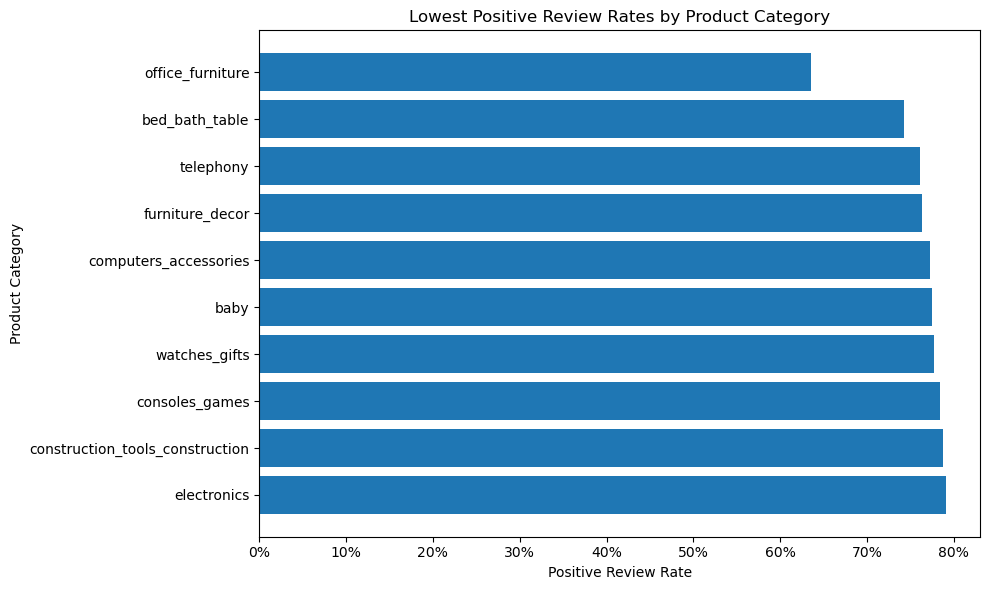

In [ ]:
# Plot positive review rate for lowest-rated major categories
plt.figure(figsize=(10, 6))

plt.barh(
    lowest_categories.index,
    lowest_categories['positive_review_rate']
)

plt.xlabel('Positive Review Rate')
plt.ylabel('Product Category')
plt.title('Lowest Positive Review Rates by Product Category')

# lowest satisfaction category appears at top
plt.gca().invert_yaxis()

plt.tight_layout()

from matplotlib.ticker import PercentFormatter
plt.gca().xaxis.set_major_formatter(PercentFormatter(1))

plt.show()

- Positive review rates varied across major product categories, indicating that customer satisfaction differed by product type.
- Office furniture had the lowest positive review rate at approximately 64%, substantially below the other major categories shown.
- Office furniture also had a notably longer average delivery time (~20 days), suggesting that delivery performance may partially contribute to its lower satisfaction.
- However, differences across categories should be interpreted as associations rather than evidence that product category itself causes lower satisfaction.

### Geographic Patterns


- Customer-level state information was used to examine whether order volume, customer satisfaction, delivery performance, and order value varied geographically across the Olist marketplace. This analysis complements the predictive modeling by evaluating regional patterns that may be relevant to retail and logistics strategy.

In [119]:
# GEOGRAPHIC ANALYSIS BY STATE

# .groupby() = split rows into groups based on each customer state
# .agg() = calculate multiple summary statistics for each group
state_summary = (
    model_df
    .groupby('customer_state')
    .agg(
        orders=('order_id', 'count'),                    # count orders per state
        positive_review_rate=('positive_review', 'mean'), # mean of 0/1 = proportion positive
        avg_delivery_days=('delivery_days', 'mean'),
        avg_delivery_delay=('delivery_delay', 'mean'),
        avg_order_value=('total_price', 'mean')
    )
    # sort states from highest → lowest number of orders
    .sort_values('orders', ascending=False)
)

state_summary.head(10)

,orders,positive_review_rate,avg_delivery_days,avg_delivery_delay,avg_order_value
customer_state,,,,,
SP,40267,0.813992,8.283731,-11.095140,125.132266
RJ,12214,0.733748,14.781890,-11.826183,142.020523
MG,11286,0.798600,11.519493,-13.263247,136.431697
RS,5326,0.798348,14.799474,-13.920954,136.350740
PR,4900,0.815306,11.507959,-13.345102,135.535969
SC,3520,0.780966,14.404261,-11.575284,141.840205
BA,3229,0.728709,18.777330,-10.896562,151.808622
DF,2070,0.788406,12.502899,-12.036232,142.721565
ES,1969,0.770950,15.152869,-10.682580,130.646668


- Customer experience varied geographically across Olist's Brazilian market.
- São Paulo (SP) had the largest order volume with 40,267 orders, an 81.4% positive review rate, and a relatively short average delivery time of 8.3 days.
- States with longer delivery times tended to show lower satisfaction in the displayed results; for example, Rio de Janeiro (RJ) had a 73.4% positive review rate and 14.8-day average delivery time, while Bahia (BA) had a 72.9% positive review rate and 18.8-day average delivery time.
- Customer state had relatively low permutation importance in the predictive model, suggesting that geography provided limited additional predictive information once delivery and other order characteristics were considered.
- Overall, the results suggest that regional differences in customer satisfaction may be related partly to differences in logistics and delivery performance rather than geography alone.

### Delivery Time and Satisfaction Across States


- Geography: identifies WHERE satisfaction is lower! (ex BA only 72.9%)
- Delivery analysis: identifies a characteristic that differs across those locations and is strongly associated with satisfaction. (ex delivery time 18.8 days for BA)
- ML: suggests the actual state label itself contributes relatively little once those order characteristics are known. (ex perm importance only 0.0016)

In [120]:
# Keep states with enough orders for a more stable comparison
# Boolean filtering: only rows where orders >= 500 are kept
state_summary_filtered = state_summary[
    state_summary['orders'] >= 500
].copy()

# .corr() = Pearson correlation between two numeric variables
# Negative value = as delivery days increase, review rate tends to decrease
state_delivery_corr = state_summary_filtered[
    'avg_delivery_days'
].corr(
    state_summary_filtered['positive_review_rate']
)

state_delivery_corr

np.float64(-0.8268127297840954)

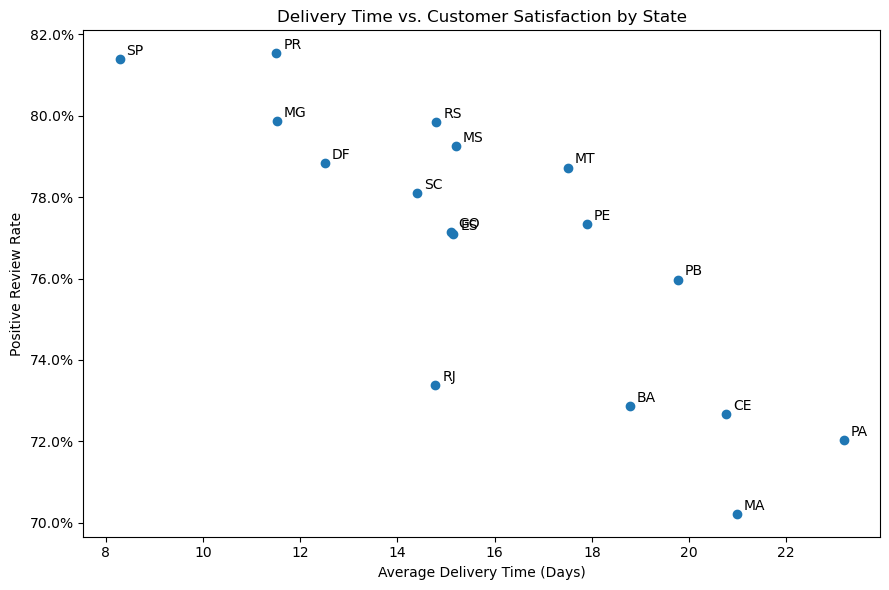

In [ ]:
# GEOGRAPHIC ANALYSIS: Delivery Time vs Satisfaction

#reuse states with at least 500 orders
state_plot = state_summary_filtered.copy()

plt.figure(figsize=(9, 6))

#scatter plot --> x = delivery time, y = satisfaction
plt.scatter(
    state_plot['avg_delivery_days'],
    state_plot['positive_review_rate']
)

#loop through each state --> index = state name, row = values for that state
for state, row in state_plot.iterrows():

    #label each point with state abbreviation
    plt.annotate(
        state,
        (row['avg_delivery_days'], row['positive_review_rate']),
        xytext=(5, 3),             #move label slightly away from point
        textcoords='offset points'
    )

plt.xlabel('Average Delivery Time (Days)')
plt.ylabel('Positive Review Rate')
plt.title('Delivery Time vs. Customer Satisfaction by State')

#change decimals --> percentages on y-axis
plt.gca().yaxis.set_major_formatter(PercentFormatter(1))

plt.tight_layout()
plt.show()

- States with longer average delivery times generally had lower positive review rates.
- Across states with at least 500 orders, average delivery time and positive review rate had a strong negative correlation (r ≈ −0.82).
- For example, São Paulo (SP) averaged approximately 8 delivery days with an 81% positive review rate, while several states averaging over 20 delivery days had positive review rates near 70–73%.
- These results suggest that geographic differences in customer satisfaction may be associated with regional delivery performance rather than location itself.
- This is consistent with the predictive model, where delivery_days was much more important than customer_state.

## 7. Final Model Comparison


In [128]:
# FINAL MODEL COMPARISON

#put results from all 3 models into one dataframe
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Accuracy': [0.813, 0.823, 0.823],
    'Precision': [0.819, 0.826, 0.826],
    'Recall': [0.979, 0.982, 0.983],
    'F1': [0.892, 0.897, 0.898],
    'ROC-AUC': [0.697, 0.697, 0.706]
})

#sort highest ROC-AUC first
model_results.sort_values('ROC-AUC', ascending=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,Gradient Boosting,0.823,0.826,0.983,0.898,0.706
0,Logistic Regression,0.813,0.819,0.979,0.892,0.697
1,Random Forest,0.823,0.826,0.982,0.897,0.697


### Compare ROC Curves


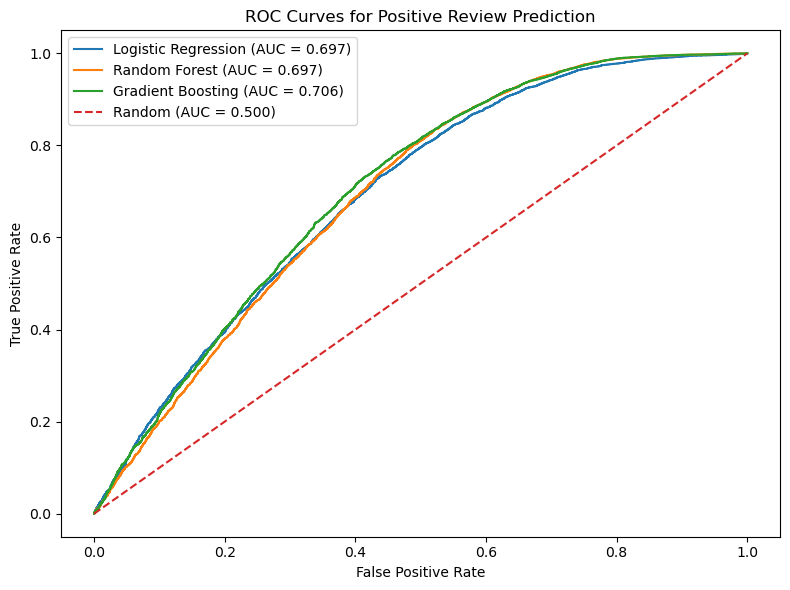

In [129]:
# ROC CURVES: Compare all 3 models

from sklearn.metrics import roc_curve, roc_auc_score

#predicted probability of positive review (class = 1)
log_prob = log_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
gb_prob = gb_model.predict_proba(X_test)[:, 1]

#find false positive rate + true positive rate at different thresholds
log_fpr, log_tpr, _ = roc_curve(y_test, log_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_prob)

plt.figure(figsize=(8, 6))

#plot each model on same graph
plt.plot(log_fpr, log_tpr, label='Logistic Regression (AUC = 0.697)')
plt.plot(rf_fpr, rf_tpr, label='Random Forest (AUC = 0.697)')
plt.plot(gb_fpr, gb_tpr, label='Gradient Boosting (AUC = 0.706)')

#random classifier baseline --> AUC = 0.50
plt.plot([0, 1], [0, 1], linestyle='--', label='Random (AUC = 0.500)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for Positive Review Prediction')
plt.legend()
plt.tight_layout()
plt.show()

- All three ROC curves remained above the random-classifier baseline, indicating predictive value beyond chance.
- Gradient Boosting achieved the highest ROC-AUC (0.706), although its improvement over Logistic Regression and Random Forest (0.697) was only modest.
- The similarity of the curves suggests that increasing model complexity provided only limited improvement.
- Overall, the available features provide moderate ability to distinguish positive from non-positive reviews.

## 8. Conclusions


Contribution: Post-purchase customer satisfaction in e-commerce is associated much more strongly with fulfillment performance and order complexity than with price, payment method, purchase timing, or geography alone.

- Delivery mattered the most for this data. On-time/early orders had about an 83% positive-review rate, compared with only 27% for late orders.
- Delivery time was the strongest predictive feature since delivery_days had the largest permutation importance, with delivery_delay also among the strongest.
- Larger orders had lower satisfaction. Positive reviews fell from about 81% for one-item orders to 55% for orders with 6+ items, even though average delivery time stayed fairly similar. That suggests order complexity contains information beyond simply taking longer to deliver.
- Product type matters somewhat: For example, office furniture had only about a 64% positive-review rate and substantially longer delivery times.
- Geography indicated where problems occur, but doesn't appear to explain much by itself. States with longer average delivery times tended to have lower satisfaction (r ≈ −0.82 across states with ≥500 orders), yet customer_state had very low predictive importance once the actual order characteristics were included.
- The ML models found a real but incomplete signal. Gradient Boosting was best at ROC-AUC ≈ 0.706. So these operational variables help predict satisfaction, but customer reviews clearly depend on factors not available in the dataset too.